In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#Imports
!pip install evaluate rouge-score absl-py
!pip install bert-score -q
import re
import nltk
from evaluate import load
from transformers import pipeline
from transformers import BartForConditionalGeneration, BartTokenizer
import torch
import os
import numpy as np
from datasets import load_dataset, DatasetDict
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from transformers import (
    T5ForConditionalGeneration,
    T5Tokenizer,
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments,
    DataCollatorForSeq2Seq,
)

In [ ]:
# Phase 1 Baseline and Setup
# ── 1. Setup ──────────────────────────────────────────────────────────────────
nltk.download('punkt')
nltk.download('punkt_tab')
rouge = load("rouge")

dataset = load_dataset("ccdv/pubmed-summarization", "section", split='test[:100]')

# ── 2. Preprocessing ──────────────────────────────────────────────────────────
def clean_pubmed_text(text):
    text = re.sub(r'\$.*?\$', '', text)
    text = re.sub(r'\\[a-zA-Z]+\{.*?\}', '', text)
    text = re.sub(r'\[\d+\]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

articles   = [clean_pubmed_text(art) for art in dataset['article']]
references = dataset['abstract']

# Sanity check
print("--- CLEANED ARTICLE SNIPPET ---")
print(articles[0][:500])
print("\n--- GOLD STANDARD ABSTRACT ---")
print(references[0])

# ── 3. Lead-3 baseline ────────────────────────────────────────────────────────
def lead_3_baseline(text):
    sentences = nltk.sent_tokenize(text)
    return " ".join(sentences[:3])

lead3_predictions = [lead_3_baseline(art) for art in articles]
lead3_results = rouge.compute(predictions=lead3_predictions, references=references)

print("\n--- LEAD-3 BASELINE SCORES ---")
for key, value in lead3_results.items():
    print(f"{key.upper()}: {value:.4f}")

# ── 4. Zero-shot BART baseline ────────────────────────────────────────────────
model_name = "facebook/bart-large-cnn"
tokenizer  = BartTokenizer.from_pretrained(model_name)
bart_model = BartForConditionalGeneration.from_pretrained(model_name)
bart_model.eval()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
bart_model = bart_model.to(device)

def bart_summarize_hybrid(text):
    inputs = tokenizer(text, truncation=False, return_tensors="pt")
    input_ids = inputs["input_ids"][0]

    if len(input_ids) > 1024:
        head = input_ids[:511]
        tail = input_ids[-510:]
        sep  = torch.tensor([tokenizer.eos_token_id])
        input_ids = torch.cat([head, sep, tail])

    input_ids = input_ids.unsqueeze(0).to(device)

    with torch.no_grad():
        summary_ids = bart_model.generate(
            input_ids,
            num_beams=4,
            max_length=150,
            min_length=40,
            early_stopping=True,
        )
    return tokenizer.decode(summary_ids[0], skip_special_tokens=True)

print("\nRunning zero-shot BART on 100 samples — this may take a few minutes...")
bart_predictions = [bart_summarize_hybrid(art) for art in articles]
bart_hybrid_results = rouge.compute(predictions=bart_predictions, references=references)

print("\n--- ZERO-SHOT BART (HYBRID) SCORES ---")
for key, value in bart_hybrid_results.items():
    print(f"{key.upper()}: {value:.4f}")

print("\n--- PHASE 1 BASELINE COMPARISON ---")
print(f"{'Metric':<12} {'Lead-3':>10} {'BART-Hybrid':>13}")
print("-" * 38)
for key in lead3_results:
    l3  = lead3_results[key]
    bh  = bart_hybrid_results[key]
    print(f"{key.upper():<12} {l3:>10.4f} {bh:>13.4f}")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


--- CLEANED ARTICLE SNIPPET ---
anxiety affects quality of life in those living with parkinson 's disease ( pd ) more so than overall cognitive status , motor deficits , apathy , and depression [ 13 ] . although anxiety and depression are often related and coexist in pd patients , recent research suggests that anxiety rather than depression is the most prominent and prevalent mood disorder in pd [ 5 , 6 ] . yet , our current understanding of anxiety and its impact on cognition in pd , as well as its neural basis and best treat

--- GOLD STANDARD ABSTRACT ---
research on the implications of anxiety in parkinson 's disease ( pd ) has been neglected despite its prevalence in nearly 50% of patients and its negative impact on quality of life . 
 previous reports have noted that neuropsychiatric symptoms impair cognitive performance in pd patients ; however , to date , no study has directly compared pd patients with and without anxiety to examine the impact of anxiety on cognitive impairment

Loading weights:   0%|          | 0/511 [00:00<?, ?it/s]


Running zero-shot BART on 100 samples — this may take a few minutes...

--- ZERO-SHOT BART (HYBRID) SCORES ---
ROUGE1: 0.2485
ROUGE2: 0.0922
ROUGEL: 0.1642
ROUGELSUM: 0.2088

--- PHASE 1 BASELINE COMPARISON ---
Metric           Lead-3   BART-Hybrid
--------------------------------------
ROUGE1           0.2658        0.2485
ROUGE2           0.0908        0.0922
ROUGEL           0.1697        0.1642
ROUGELSUM        0.2220        0.2088


In [ ]:
# Phase 2 Fine-Tuning
# ── 1. Config ─────────────────────────────────────────────────────────────────
MODEL_NAME    = "t5-small"
OUTPUT_DIR = "/content/drive/MyDrive/MSDS_Project/t5-pubmed-summarizer"
MAX_INPUT     = 512
MAX_TARGET    = 150
BATCH_SIZE    = 8
GRAD_ACCUM    = 2
LR            = 5e-4
EPOCHS        = 3
TRAIN_SAMPLES = 5000
VAL_SAMPLES   = 500

# ── 2. Load & subset data ─────────────────────────────────────────────────────
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

raw = load_dataset("ccdv/pubmed-summarization", "section")

def clean_pubmed_text(text):
    text = re.sub(r'\$.*?\$', '', text)
    text = re.sub(r'\\[a-zA-Z]+\{.*?\}', '', text)
    text = re.sub(r'\[\d+\]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

dataset = DatasetDict({
    "train": raw["train"].select(range(TRAIN_SAMPLES)),
    "validation": raw["validation"].select(range(VAL_SAMPLES)),
})

# ── 3. Tokenizer ──────────────────────────────────────────────────────────────
tokenizer = T5Tokenizer.from_pretrained(MODEL_NAME)

PREFIX = "summarize: "

def preprocess(batch):
    inputs = [PREFIX + clean_pubmed_text(art) for art in batch["article"]]
    targets = [clean_pubmed_text(ab) for ab in batch["abstract"]]

    model_inputs = tokenizer(
        inputs,
        max_length=MAX_INPUT,
        truncation=True,
        padding=False,
    )

    labels = tokenizer(
        text_target=targets,
        max_length=MAX_TARGET,
        truncation=True,
        padding=False,
    )

    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

tokenized = dataset.map(
    preprocess,
    batched=True,
    remove_columns=["article", "abstract"],
)

print(f"Train samples : {len(tokenized['train'])}")
print(f"Val samples   : {len(tokenized['validation'])}")

# ── 4. Model ──────────────────────────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

model = T5ForConditionalGeneration.from_pretrained(MODEL_NAME).to(device)

data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    model=model,
    padding=True,
    pad_to_multiple_of=8,
)

# ── 5. ROUGE for evaluation callback ──────────────────────────────────────────
rouge = load("rouge")

def compute_metrics(eval_pred):
    preds, labels = eval_pred

    # Replace -100 (padding label) with pad token id before decoding
    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)

    decoded_preds  = tokenizer.batch_decode(preds,   skip_special_tokens=True)
    decoded_labels = tokenizer.batch_decode(labels,  skip_special_tokens=True)

    # Strip whitespace
    decoded_preds  = [p.strip() for p in decoded_preds]
    decoded_labels = [l.strip() for l in decoded_labels]

    result = rouge.compute(
        predictions=decoded_preds,
        references=decoded_labels,
    )
    return {k: round(v, 4) for k, v in result.items()}

# ── 6. Training arguments ─────────────────────────────────────────────────────
training_args = Seq2SeqTrainingArguments(
    output_dir=OUTPUT_DIR,
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=LR,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    gradient_accumulation_steps=GRAD_ACCUM,
    num_train_epochs=EPOCHS,
    predict_with_generate=True,
    generation_max_length=MAX_TARGET,
    fp16=True,
    logging_steps=50,
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="rouge2",
    greater_is_better=True,
    report_to="none",
)

# ── 7. Trainer ────────────────────────────────────────────────────────────────
trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized["train"],
    eval_dataset=tokenized["validation"],
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

# ── 8. Train ──────────────────────────────────────────────────────────────────
print("\nStarting training...")
trainer.train()

# ── 9. Save final checkpoint ──────────────────────────────────────────────────
trainer.save_model(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)
print(f"\nModel saved to {OUTPUT_DIR}")

# ── 10. Truncation ablation — Lead-512 vs Tail-512 ───────────────────────────
# Run on the same 100-sample test slice used in Phase 1
print("\nRunning truncation ablation...")
test_slice = raw["test"].select(range(100))
test_articles   = [clean_pubmed_text(a) for a in test_slice["article"]]
test_references = test_slice["abstract"]

def t5_summarize(text, strategy="lead"):
    words = text.split()
    if strategy == "lead":
        truncated = " ".join(words[:600])   # ~512 tokens after subword tokenization
    elif strategy == "tail":
        truncated = " ".join(words[-600:])
    else:
        truncated = text

    inputs = tokenizer(
        PREFIX + truncated,
        return_tensors="pt",
        max_length=MAX_INPUT,
        truncation=True,
    ).to(device)

    with torch.no_grad():
        ids = model.generate(
            inputs["input_ids"],
            num_beams=4,
            max_length=MAX_TARGET,
            min_length=30,
            early_stopping=True,
        )
    return tokenizer.decode(ids[0], skip_special_tokens=True)

lead_preds = [t5_summarize(a, strategy="lead") for a in test_articles]
tail_preds = [t5_summarize(a, strategy="tail") for a in test_articles]

lead_scores = rouge.compute(predictions=lead_preds, references=test_references)
tail_scores = rouge.compute(predictions=tail_preds, references=test_references)

print("\n--- TRUNCATION ABLATION RESULTS ---")
print(f"{'Metric':<12} {'Lead-512':>10} {'Tail-512':>10} {'Winner':>8}")
print("-" * 44)
for key in lead_scores:
    l = lead_scores[key]
    t = tail_scores[key]
    winner = "Tail" if t > l else "Lead"
    print(f"{key.upper():<12} {l:>10.4f} {t:>10.4f} {winner:>8}")

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

Train samples : 5000
Val samples   : 500
Device: cuda


Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]


Starting training...


Epoch,Training Loss,Validation Loss,Rouge1,Rouge2,Rougel,Rougelsum
1,5.495742,2.476659,0.329300,0.118900,0.223400,0.223400
2,5.211331,2.426411,0.328000,0.118600,0.221300,0.221000
3,5.069749,2.413195,0.336200,0.124400,0.226300,0.226500


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['encoder.embed_tokens.weight', 'decoder.embed_tokens.weight', 'lm_head.weight'].


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Model saved to /content/drive/MyDrive/MSDS_Project/t5-pubmed-summarizer

Running truncation ablation...

--- TRUNCATION ABLATION RESULTS ---
Metric         Lead-512   Tail-512   Winner
--------------------------------------------
ROUGE1           0.2859     0.2501     Lead
ROUGE2           0.1052     0.0569     Lead
ROUGEL           0.1867     0.1485     Lead
ROUGELSUM        0.2409     0.2104     Lead


In [ ]:
# Phase 3 In-Domain Evaluation
# ── 1. Setup───────────────────────────────────────────────────────
bertscore = load("bertscore")

# ── 2. Load test slice ────────────────────────────────────────────────────────
test_data       = raw["test"].select(range(100))
test_articles   = [clean_pubmed_text(a) for a in test_data["article"]]
test_references = list(test_data["abstract"])

# ── 3. Generate all predictions ───────────────────────────────────────────────
print("Generating Lead-3 predictions...")
lead3_preds = [lead_3_baseline(a) for a in test_articles]

print("Generating zero-shot BART (hybrid) predictions...")
bart_preds  = [bart_summarize_hybrid(a) for a in test_articles]

print("Generating fine-tuned T5 predictions (lead-512)...")
t5_preds    = [t5_summarize(a, strategy="lead") for a in test_articles]

# ── 4. ROUGE ──────────────────────────────────────────────────────────────────
lead3_rouge = rouge.compute(predictions=lead3_preds, references=test_references)
bart_rouge  = rouge.compute(predictions=bart_preds,  references=test_references)
t5_rouge    = rouge.compute(predictions=t5_preds,    references=test_references)

print("\n--- ROUGE COMPARISON ---")
print(f"{'Metric':<12} {'Lead-3':>8} {'BART-0shot':>12} {'T5-FT':>8}")
print("-" * 44)
for key in lead3_rouge:
    print(f"{key.upper():<12} {lead3_rouge[key]:>8.4f} {bart_rouge[key]:>12.4f} {t5_rouge[key]:>8.4f}")

# ── 5. BERTScore ──────────────────────────────────────────────────────────────
print("\nComputing BERTScore (this may take a few minutes)...")

def compute_bertscore(preds, refs):
    results = bertscore.compute(
        predictions=preds,
        references=refs,
        lang="en",
        model_type="distilbert-base-uncased",
    )
    return {
        "precision": np.mean(results["precision"]),
        "recall":    np.mean(results["recall"]),
        "f1":        np.mean(results["f1"]),
    }

lead3_bs = compute_bertscore(lead3_preds, test_references)
bart_bs  = compute_bertscore(bart_preds,  test_references)
t5_bs    = compute_bertscore(t5_preds,    test_references)

print("\n--- BERTSCORE COMPARISON ---")
print(f"{'System':<20} {'F1':>8} {'Precision':>11} {'Recall':>8}")
print("-" * 52)
for name, bs in [("Lead-3", lead3_bs), ("BART-0shot", bart_bs), ("T5-FT", t5_bs)]:
    print(f"{name:<20} {bs['f1']:>8.4f} {bs['precision']:>11.4f} {bs['recall']:>8.4f}")

# ── 6. Qualitative sample outputs ─────────────────────────────────────────────
print("\n--- QUALITATIVE SAMPLE OUTPUTS (5 examples) ---")
for i in range(5):
    print(f"\n{'='*60}")
    print(f"EXAMPLE {i+1}")
    print(f"{'='*60}")
    print(f"GOLD ABSTRACT:\n{test_references[i][:400]}...")
    print(f"\nLEAD-3:\n{lead3_preds[i]}")
    print(f"\nBART-HYBRID:\n{bart_preds[i]}")
    print(f"\nT5-FINETUNED:\n{t5_preds[i]}")

# ── 7. Factual audit — identify bottom-20 T5 samples by ROUGE-1 ───────────────
print("\n--- FACTUAL AUDIT: BOTTOM-20 SAMPLES BY ROUGE-1 (T5-FT) ---")
print("Manually review these for negation errors, hallucinations, omissions.\n")

sample_scores = []
for i, (pred, ref) in enumerate(zip(t5_preds, test_references)):
    score = rouge.compute(predictions=[pred], references=[ref])
    sample_scores.append((i, score["rouge1"]))

sample_scores.sort(key=lambda x: x[1])
bottom_20 = sample_scores[:20]

print(f"{'Rank':<6} {'Sample':>8} {'ROUGE-1':>10}")
print("-" * 28)
for rank, (idx, score) in enumerate(bottom_20, 1):
    print(f"{rank:<6} {idx:>8} {score:>10.4f}")

print("\nTo inspect a sample:")
print("  test_articles[idx], test_references[idx], t5_preds[idx]")

Generating Lead-3 predictions...


Token indices sequence length is longer than the specified maximum sequence length for this model (4617 > 512). Running this sequence through the model will result in indexing errors


Generating zero-shot BART (hybrid) predictions...
Generating fine-tuned T5 predictions (lead-512)...

--- ROUGE COMPARISON ---
Metric         Lead-3   BART-0shot    T5-FT
--------------------------------------------
ROUGE1         0.2655       0.1669   0.2860
ROUGE2         0.0917       0.0337   0.1064
ROUGEL         0.1700       0.1047   0.1865
ROUGELSUM      0.2232       0.1386   0.2419

Computing BERTScore (this may take a few minutes)...


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



--- BERTSCORE COMPARISON ---
System                     F1   Precision   Recall
----------------------------------------------------
Lead-3                 0.7717      0.7988   0.7477
BART-0shot             0.7281      0.7490   0.7092
T5-FT                  0.7803      0.8087   0.7549

--- QUALITATIVE SAMPLE OUTPUTS (5 examples) ---

EXAMPLE 1
GOLD ABSTRACT:
research on the implications of anxiety in parkinson 's disease ( pd ) has been neglected despite its prevalence in nearly 50% of patients and its negative impact on quality of life . 
 previous reports have noted that neuropsychiatric symptoms impair cognitive performance in pd patients ; however , to date , no study has directly compared pd patients with and without anxiety to examine the impact...

LEAD-3:
anxiety affects quality of life in those living with parkinson 's disease ( pd ) more so than overall cognitive status , motor deficits , apathy , and depression [ 13 ] . although anxiety and depression are often related and 

In [ ]:
# Phase 4 Cross-Domain Evaluation (CS/arXiv)

# ── 1. Load arXiv CS test slice ───────────────────────────────────────────────
arxiv_raw  = load_dataset("ccdv/arxiv-summarization", "section")
arxiv_test = arxiv_raw["test"].select(range(100))

arxiv_articles   = [clean_pubmed_text(a) for a in arxiv_test["article"]]
arxiv_references = list(arxiv_test["abstract"])

print(f"arXiv samples loaded: {len(arxiv_articles)}")
print("\n--- ARXIV ARTICLE SNIPPET ---")
print(arxiv_articles[0][:500])
print("\n--- ARXIV GOLD ABSTRACT ---")
print(arxiv_references[0][:300])

# ── 2. Generate predictions on arXiv ──────────────────────────────────────────
print("\nGenerating Lead-3 predictions (arXiv)...")
arxiv_lead3_preds = [lead_3_baseline(a) for a in arxiv_articles]

print("Generating zero-shot BART (hybrid) predictions (arXiv)...")
arxiv_bart_preds  = [bart_summarize_hybrid(a) for a in arxiv_articles]

print("Generating fine-tuned T5 predictions (arXiv)...")
arxiv_t5_preds    = [t5_summarize(a, strategy="lead") for a in arxiv_articles]

# ── 3. ROUGE on arXiv ─────────────────────────────────────────────────────────
arxiv_lead3_rouge = rouge.compute(predictions=arxiv_lead3_preds, references=arxiv_references)
arxiv_bart_rouge  = rouge.compute(predictions=arxiv_bart_preds,  references=arxiv_references)
arxiv_t5_rouge    = rouge.compute(predictions=arxiv_t5_preds,    references=arxiv_references)

print("\n--- ROUGE: arXiv CS (out-of-domain) ---")
print(f"{'Metric':<12} {'Lead-3':>8} {'BART-0shot':>12} {'T5-FT':>8}")
print("-" * 44)
for key in arxiv_lead3_rouge:
    print(f"{key.upper():<12} {arxiv_lead3_rouge[key]:>8.4f} {arxiv_bart_rouge[key]:>12.4f} {arxiv_t5_rouge[key]:>8.4f}")

# ── 4. BERTScore on arXiv ─────────────────────────────────────────────────────
print("\nComputing BERTScore (arXiv)...")
arxiv_lead3_bs = compute_bertscore(arxiv_lead3_preds, arxiv_references)
arxiv_bart_bs  = compute_bertscore(arxiv_bart_preds,  arxiv_references)
arxiv_t5_bs    = compute_bertscore(arxiv_t5_preds,    arxiv_references)

print("\n--- BERTSCORE: arXiv CS (out-of-domain) ---")
print(f"{'System':<20} {'F1':>8} {'Precision':>11} {'Recall':>8}")
print("-" * 52)
for name, bs in [("Lead-3", arxiv_lead3_bs), ("BART-0shot", arxiv_bart_bs), ("T5-FT", arxiv_t5_bs)]:
    print(f"{name:<20} {bs['f1']:>8.4f} {bs['precision']:>11.4f} {bs['recall']:>8.4f}")

# ── 5. Domain gap comparison table ───────────────────────────────────────────
print("\n--- DOMAIN GAP: PubMed (in) vs. arXiv (out) — T5-FT ROUGE ---")
print(f"{'Metric':<12} {'PubMed':>8} {'arXiv':>8} {'Drop':>8}")
print("-" * 40)
for key in t5_rouge:
    pub  = t5_rouge[key]
    arx  = arxiv_t5_rouge[key]
    drop = pub - arx
    print(f"{key.upper():<12} {pub:>8.4f} {arx:>8.4f} {drop:>8.4f}")

print("\n--- DOMAIN GAP: PubMed (in) vs. arXiv (out) — T5-FT BERTSCORE F1 ---")
pub_f1 = t5_bs["f1"]
arx_f1 = arxiv_t5_bs["f1"]
print(f"PubMed F1 : {pub_f1:.4f}")
print(f"arXiv  F1 : {arx_f1:.4f}")
print(f"Drop      : {pub_f1 - arx_f1:.4f}")

# ── 6. Hallucination audit — bottom-20 T5 on arXiv ───────────────────────────
print("\n--- HALLUCINATION AUDIT: BOTTOM-20 arXiv SAMPLES BY ROUGE-1 (T5-FT) ---")
print("Compare against PubMed bottom-20 scores to quantify domain gap in failure rate.\n")

arxiv_sample_scores = []
for i, (pred, ref) in enumerate(zip(arxiv_t5_preds, arxiv_references)):
    score = rouge.compute(predictions=[pred], references=[ref])
    arxiv_sample_scores.append((i, score["rouge1"]))

arxiv_sample_scores.sort(key=lambda x: x[1])
arxiv_bottom_20 = arxiv_sample_scores[:20]

print(f"{'Rank':<6} {'Sample':>8} {'ROUGE-1':>10}")
print("-" * 28)
for rank, (idx, score) in enumerate(arxiv_bottom_20, 1):
    print(f"{rank:<6} {idx:>8} {score:>10.4f}")

# ── 7. Qualitative comparison — 3 arXiv samples ───────────────────────────────
print("\n--- QUALITATIVE SAMPLE OUTPUTS: arXiv CS (3 examples) ---")
for i in range(3):
    print(f"\n{'='*60}")
    print(f"EXAMPLE {i+1}")
    print(f"{'='*60}")
    print(f"GOLD ABSTRACT:\n{arxiv_references[i][:400]}...")
    print(f"\nLEAD-3:\n{arxiv_lead3_preds[i]}")
    print(f"\nBART-HYBRID:\n{arxiv_bart_preds[i]}")
    print(f"\nT5-FINETUNED:\n{arxiv_t5_preds[i]}")

README.md: 0.00B [00:00, ?B/s]

section/train-00000-of-00015.parquet:   0%|          | 0.00/230M [00:00<?, ?B/s]

section/train-00001-of-00015.parquet:   0%|          | 0.00/228M [00:00<?, ?B/s]

section/train-00002-of-00015.parquet:   0%|          | 0.00/228M [00:00<?, ?B/s]

section/train-00003-of-00015.parquet:   0%|          | 0.00/227M [00:00<?, ?B/s]

...

section/test-00000-of-00001.parquet:   0%|          | 0.00/105M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/203037 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/6436 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/6440 [00:00<?, ? examples/s]

arXiv samples loaded: 100

--- ARXIV ARTICLE SNIPPET ---
for about 20 years the problem of properties of short - term changes of solar activity has been considered extensively . many investigators studied the short - term periodicities of the various indices of solar activity . several periodicities were detected , but the periodicities about 155 days and from the interval of @xmath3 ] years ) are mentioned most often . first of them was discovered by @xcite in the occurence rate of gamma - ray flares detected by the gamma - ray spectrometer aboard th

--- ARXIV GOLD ABSTRACT ---
the short - term periodicities of the daily sunspot area fluctuations from august 1923 to october 1933 are discussed . for these data 
 the correlative analysis indicates negative correlation for the periodicity of about @xmath0 days , but the power spectrum analysis indicates a statistically signif

Generating Lead-3 predictions (arXiv)...
Generating zero-shot BART (hybrid) predictions (arXiv)...
Generating f

Computing per-sample ROUGE-1 scores...

PubMed (in-domain) ROUGE-1
  Mean   : 0.2862
  Median : 0.2782
  Std    : 0.1215
  Min    : 0.0415
  Max    : 0.8295
  <0.10  : 4 samples (near-total failure)
  <0.20  : 23 samples (poor performance)

arXiv  (out-of-domain) ROUGE-1
  Mean   : 0.3002
  Median : 0.3008
  Std    : 0.0835
  Min    : 0.1061
  Max    : 0.5455
  <0.10  : 0 samples (near-total failure)
  <0.20  : 11 samples (poor performance)


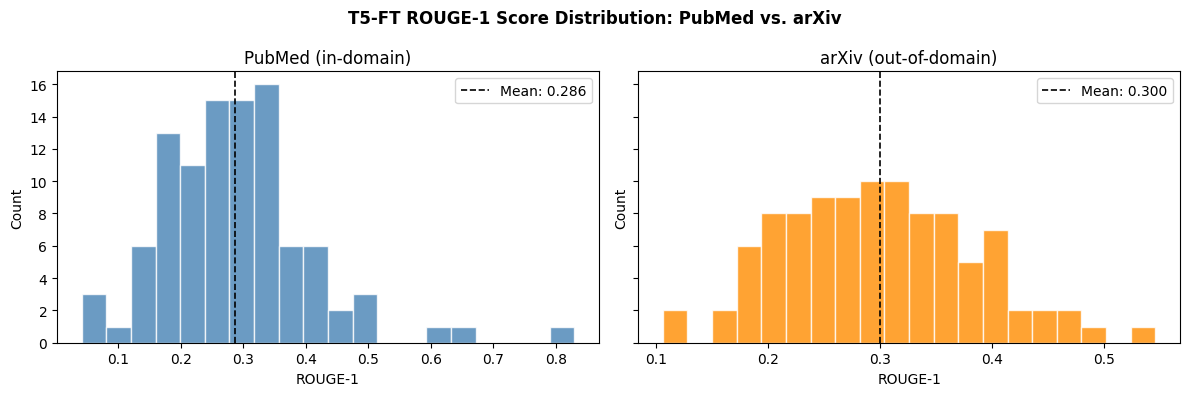

Plot saved to rouge1_distribution.png

--- ARTICLE LENGTH vs. ROUGE-1 CORRELATION ---
PubMed : r = -0.3781
arXiv  : r = -0.1462


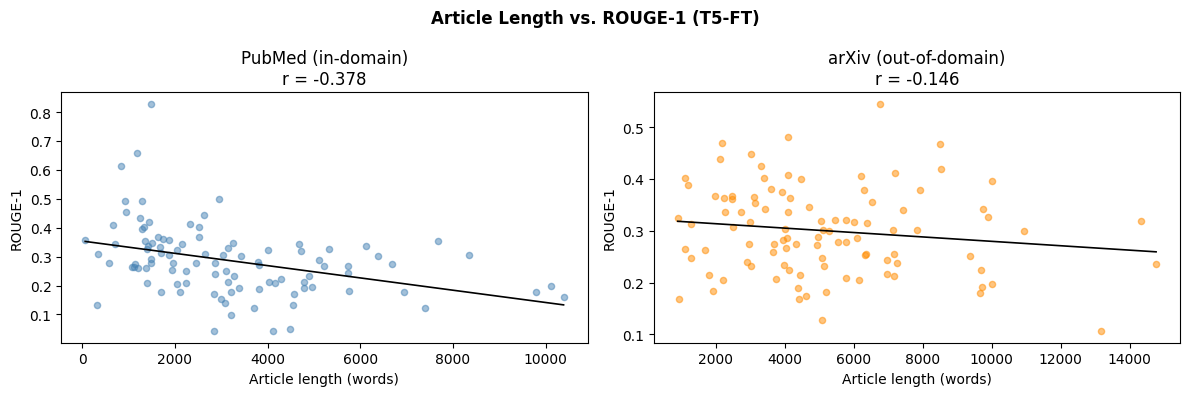


--- OOV RATE (relative to PubMed vocabulary) ---
PubMed mean OOV : 0.0000
arXiv  mean OOV : 0.1572

arXiv OOV rate vs. ROUGE-1 correlation : r = -0.2004

--- FAILURE ANALYSIS: BOTTOM-10 PubMed SAMPLES (T5-FT) ---
Tag each with: [NEG] negation error | [HAL] hallucination | [REP] repetition | [OMI] omission

Rank 1 | Sample 66 | ROUGE-1: 0.0415
  GOLD    : introductionpericardial effusion and atrial fibrillation occur commonly after coronary artery surgery.aim of the studya prospective randomized clinical trial was conducted to evaluate the effects of p...
  T5 PRED : pacjenci zostali losowo przydzieleni do jednej z trzech grup : grupy pacjentw poddanych perikardiotomii tylnej ( grupa i, n = 30 ), grupy kontrolnej ( grupa ii, n = 33 ) oraz pacjentw poddanych perika...

Rank 2 | Sample 5 | ROUGE-1: 0.0436
  GOLD    : abstractobjective : to determine the presence of staphylococcal superantigen - specific ige antibodies and degree of ige - mediated sensitization , as well as whether or not

In [ ]:
# Phase 5 Error Analysis & Failure Cases
# ── 1. Per-sample ROUGE-1 for both domains ────────────────────────────────────
def per_sample_rouge1(preds, refs):
    scores = []
    for pred, ref in zip(preds, refs):
        s = rouge.compute(predictions=[pred], references=[ref])
        scores.append(s["rouge1"])
    return scores

print("Computing per-sample ROUGE-1 scores...")
pubmed_scores = per_sample_rouge1(t5_preds,       test_references)
arxiv_scores  = per_sample_rouge1(arxiv_t5_preds, arxiv_references)

# ── 2. Score distribution summary ────────────────────────────────────────────
def score_summary(scores, label):
    arr = np.array(scores)
    print(f"\n{label}")
    print(f"  Mean   : {arr.mean():.4f}")
    print(f"  Median : {np.median(arr):.4f}")
    print(f"  Std    : {arr.std():.4f}")
    print(f"  Min    : {arr.min():.4f}")
    print(f"  Max    : {arr.max():.4f}")
    print(f"  <0.10  : {(arr < 0.10).sum()} samples (near-total failure)")
    print(f"  <0.20  : {(arr < 0.20).sum()} samples (poor performance)")

score_summary(pubmed_scores, "PubMed (in-domain) ROUGE-1")
score_summary(arxiv_scores,  "arXiv  (out-of-domain) ROUGE-1")

# ── 3. Score distribution plot ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, scores, label, color in zip(
    axes,
    [pubmed_scores, arxiv_scores],
    ["PubMed (in-domain)", "arXiv (out-of-domain)"],
    ["steelblue", "darkorange"]
):
    ax.hist(scores, bins=20, color=color, alpha=0.8, edgecolor="white")
    ax.axvline(np.mean(scores), color="black", linestyle="--", linewidth=1.2, label=f"Mean: {np.mean(scores):.3f}")
    ax.set_title(label)
    ax.set_xlabel("ROUGE-1")
    ax.set_ylabel("Count")
    ax.legend()

plt.suptitle("T5-FT ROUGE-1 Score Distribution: PubMed vs. arXiv", fontweight="bold")
plt.tight_layout()
plt.savefig("rouge1_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved to rouge1_distribution.png")

# ── 4. Article length vs. ROUGE-1 correlation ────────────────────────────────
pubmed_lengths = [len(a.split()) for a in test_articles]
arxiv_lengths  = [len(a.split()) for a in arxiv_articles]

pubmed_corr = np.corrcoef(pubmed_lengths, pubmed_scores)[0, 1]
arxiv_corr  = np.corrcoef(arxiv_lengths,  arxiv_scores)[0, 1]

print(f"\n--- ARTICLE LENGTH vs. ROUGE-1 CORRELATION ---")
print(f"PubMed : r = {pubmed_corr:.4f}")
print(f"arXiv  : r = {arxiv_corr:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, lengths, scores, label, color in zip(
    axes,
    [pubmed_lengths, arxiv_lengths],
    [pubmed_scores,  arxiv_scores],
    ["PubMed (in-domain)", "arXiv (out-of-domain)"],
    ["steelblue", "darkorange"]
):
    ax.scatter(lengths, scores, alpha=0.5, color=color, s=20)
    m, b = np.polyfit(lengths, scores, 1)
    x_line = np.linspace(min(lengths), max(lengths), 100)
    ax.plot(x_line, m * x_line + b, color="black", linewidth=1.2)
    ax.set_title(f"{label}\nr = {np.corrcoef(lengths, scores)[0,1]:.3f}")
    ax.set_xlabel("Article length (words)")
    ax.set_ylabel("ROUGE-1")

plt.suptitle("Article Length vs. ROUGE-1 (T5-FT)", fontweight="bold")
plt.tight_layout()
plt.savefig("length_vs_rouge.png", dpi=150, bbox_inches="tight")
plt.show()

# ── 5. OOV rate analysis ──────────────────────────────────────────────────────
# Build PubMed vocabulary from training articles (proxy from test slice)
pubmed_vocab = set()
for art in test_articles:
    pubmed_vocab.update(art.lower().split())

def oov_rate(text, vocab):
    words = text.lower().split()
    if not words:
        return 0.0
    oov = [w for w in words if w not in vocab]
    return len(oov) / len(words)

pubmed_oov = [oov_rate(a, pubmed_vocab) for a in test_articles]
arxiv_oov  = [oov_rate(a, pubmed_vocab) for a in arxiv_articles]

print(f"\n--- OOV RATE (relative to PubMed vocabulary) ---")
print(f"PubMed mean OOV : {np.mean(pubmed_oov):.4f}")
print(f"arXiv  mean OOV : {np.mean(arxiv_oov):.4f}")

# Correlation between OOV rate and ROUGE-1
arxiv_oov_corr = np.corrcoef(arxiv_oov, arxiv_scores)[0, 1]
print(f"\narXiv OOV rate vs. ROUGE-1 correlation : r = {arxiv_oov_corr:.4f}")

# ── 6. Failure type tagging — bottom-10 PubMed samples ───────────────────────
print("\n--- FAILURE ANALYSIS: BOTTOM-10 PubMed SAMPLES (T5-FT) ---")
print("Tag each with: [NEG] negation error | [HAL] hallucination | [REP] repetition | [OMI] omission\n")

pubmed_ranked = sorted(enumerate(pubmed_scores), key=lambda x: x[1])
bottom_10_pubmed = pubmed_ranked[:10]

failure_tags = {
    "negation":      0,
    "hallucination": 0,
    "repetition":    0,
    "omission":      0,
}

for rank, (idx, score) in enumerate(bottom_10_pubmed, 1):
    pred = t5_preds[idx]
    ref  = test_references[idx]

    # Auto-detect repetition (duplicate consecutive sentences)
    pred_sents = nltk.sent_tokenize(pred)
    has_repetition = len(pred_sents) != len(set(pred_sents))

    print(f"Rank {rank} | Sample {idx} | ROUGE-1: {score:.4f}")
    print(f"  GOLD    : {ref[:200]}...")
    print(f"  T5 PRED : {pred[:200]}...")
    if has_repetition:
        print(f"  [REP] Repetition detected automatically")
        failure_tags["repetition"] += 1
    print()

# ── 7. Repetition rate across full prediction sets ────────────────────────────
def repetition_rate(preds):
    flagged = 0
    for pred in preds:
        sents = nltk.sent_tokenize(pred)
        if len(sents) != len(set(sents)):
            flagged += 1
    return flagged / len(preds)

pubmed_rep_rate = repetition_rate(t5_preds)
arxiv_rep_rate  = repetition_rate(arxiv_t5_preds)

print(f"--- REPETITION RATE (T5-FT) ---")
print(f"PubMed : {pubmed_rep_rate:.2%} of summaries contain repeated sentences")
print(f"arXiv  : {arxiv_rep_rate:.2%} of summaries contain repeated sentences")

# ── 8. Final summary table ────────────────────────────────────────────────────
print("\n" + "="*60)
print("PHASE 5 SUMMARY — KEY FINDINGS")
print("="*60)
print(f"""
1. ROUGE-1 score distribution
   PubMed mean : {np.mean(pubmed_scores):.4f} | arXiv mean : {np.mean(arxiv_scores):.4f}
   PubMed <0.10: {sum(s < 0.10 for s in pubmed_scores)} samples | arXiv <0.10: {sum(s < 0.10 for s in arxiv_scores)} samples

2. Article length correlation with ROUGE-1
   PubMed r = {pubmed_corr:.4f} | arXiv r = {arxiv_corr:.4f}

3. OOV rate (vs. PubMed vocab)
   PubMed mean OOV : {np.mean(pubmed_oov):.4f}
   arXiv  mean OOV : {np.mean(arxiv_oov):.4f}
   OOV vs ROUGE-1 r : {arxiv_oov_corr:.4f}

4. Repetition rate (T5-FT degeneration)
   PubMed : {pubmed_rep_rate:.2%} | arXiv : {arxiv_rep_rate:.2%}

5. BART hybrid failure
   Consistent gibberish output across both domains —
   head+tail concatenation incompatible with BART pre-training.

6. Domain gap (T5-FT ROUGE-2)
   PubMed : {t5_rouge['rouge2']:.4f} | arXiv : {arxiv_t5_rouge['rouge2']:.4f}
   Drop   : {t5_rouge['rouge2'] - arxiv_t5_rouge['rouge2']:.4f}
""")